In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import os
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr, kruskal, ttest_ind, mannwhitneyu
import scikit_posthocs as sp
from sklearn.metrics import r2_score
import json
import tifffile as tiff
from skimage import measure
from shapely.geometry import Polygon
import geopandas as gpd
from skimage import morphology

In [11]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/plots/figures/figure_1/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/plots/figures/suppl_figure_1/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [12]:
df = adata.obs.copy()
df

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [131]:
adata.to_df().head()

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,GLUT1,GranzymeB,Ki67,CollagenTypeI,CD3,CPT1A,CD98,HLA-DR,ST6GAL1,CD138
Object 1 in TS-373_IMC77_B_001.csv,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,0.829930,0.303835,0.133152,0.698834,0.785446,0.734610,0.277531,0.523756,0.136619,0.104558
Object 2 in TS-373_IMC77_B_001.csv,0.437678,0.425806,0.730220,0.539852,0.814078,0.153551,0.202306,0.000000,0.670883,0.632502,...,0.821824,0.784683,0.651934,0.230406,0.339345,0.607873,0.293819,0.393568,0.519122,0.038556
Object 3 in TS-373_IMC77_B_001.csv,0.187705,0.185489,1.009269,0.506163,0.770498,0.041015,0.347042,0.075689,0.889004,0.901242,...,0.541370,0.554571,0.294199,0.000000,0.197589,0.338899,0.236579,0.281655,0.390412,0.041015
Object 4 in TS-373_IMC77_B_001.csv,0.367975,0.144265,0.593424,0.173114,0.517508,0.062037,0.253639,0.199798,0.712216,0.430238,...,1.025051,0.331828,0.368753,0.000000,0.101981,0.470288,0.128798,0.467415,0.601154,0.000000
Object 5 in TS-373_IMC77_B_001.csv,0.544195,0.216297,0.881555,0.338833,0.487923,0.049646,0.195340,0.000000,0.475726,0.511521,...,0.760665,0.432045,0.831870,0.035482,0.162274,0.517464,0.437695,0.467406,0.406909,0.108879


In [84]:
mask = tiff.imread('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/MK masks/TS-373_IMC83_B_001.tiff')

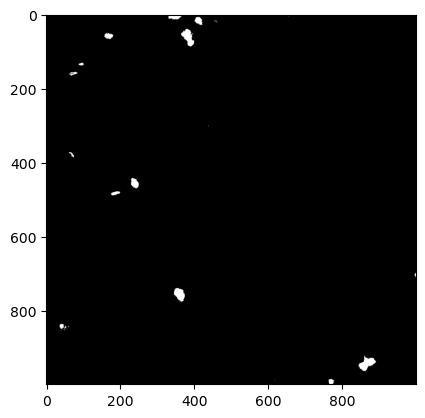

In [85]:
plt.imshow(mask, cmap='gray_r')

In [15]:
mask.min()

np.uint8(1)

In [16]:
mask.max()

np.uint8(2)

In [17]:
unique, counts = np.unique(mask, return_counts=True)
pd.Series(counts, index=unique).sort_index()

1      3064
2    996936
dtype: int64

In [89]:
binary_mask = (mask == 1).astype(np.uint8)
binary_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [90]:
MIN_PIXEL_AREA = 200
binary_mask = morphology.remove_small_objects(binary_mask, min_size=MIN_PIXEL_AREA).astype(np.uint8)
contours = measure.find_contours(binary_mask, 0.5)
contours

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/3392513321.py:2: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  binary_mask = morphology.remove_small_objects(binary_mask, min_size=MIN_PIXEL_AREA).astype(np.uint8)


[array([[  0. , 329.5],
        [  0.5, 329. ],
        [  0.5, 328. ],
        [  0.5, 327. ],
        [  0. , 326.5]]),
 array([[  0. , 365.5],
        [  1. , 365.5],
        [  2. , 365.5],
        [  2.5, 366. ],
        [  3. , 366.5],
        [  4. , 366.5],
        [  4.5, 366. ],
        [  5. , 365.5],
        [  6. , 365.5],
        [  6.5, 365. ],
        [  7. , 364.5],
        [  7.5, 364. ],
        [  8. , 363.5],
        [  8.5, 363. ],
        [  8.5, 362. ],
        [  9. , 361.5],
        [  9.5, 361. ],
        [ 10. , 360.5],
        [ 10.5, 360. ],
        [ 11. , 359.5],
        [ 11.5, 359. ],
        [ 12. , 358.5],
        [ 12.5, 358. ],
        [ 13. , 357.5],
        [ 13.5, 357. ],
        [ 13.5, 356. ],
        [ 13.5, 355. ],
        [ 13. , 354.5],
        [ 12.5, 354. ],
        [ 13. , 353.5],
        [ 13.5, 353. ],
        [ 14. , 352.5],
        [ 14.5, 352. ],
        [ 14.5, 351. ],
        [ 14. , 350.5],
        [ 13. , 350.5],
        [ 12.5

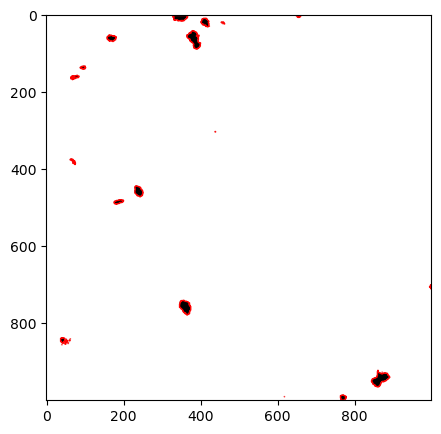

In [92]:
polygon_list = []
for contour in contours:
    contour = contour[:, [1, 0]]
    polygon = mpatches.Polygon(contour, closed=True, fill=False, edgecolor='red', linewidth=1)
    polygon_list.append(polygon)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(binary_mask, cmap='gray_r')
for polygon in polygon_list:
    ax.add_patch(polygon)
plt.show()

In [51]:
polygon_list = []
for contour in contours:
    polygon_verts = contour[:, [1, 0]]
    polygon_list.append(Polygon(polygon_verts))

## Sanity check

In [36]:
test = polygon_list[0]
area = test.area
area

2.5

In [52]:
areas = [polygon.area for polygon in polygon_list]
areas_series = pd.Series(areas)
areas_series.describe()

count      28.000000
mean      245.321429
std       320.992795
min         0.500000
25%         3.000000
50%       150.500000
75%       345.750000
max      1147.500000
dtype: float64

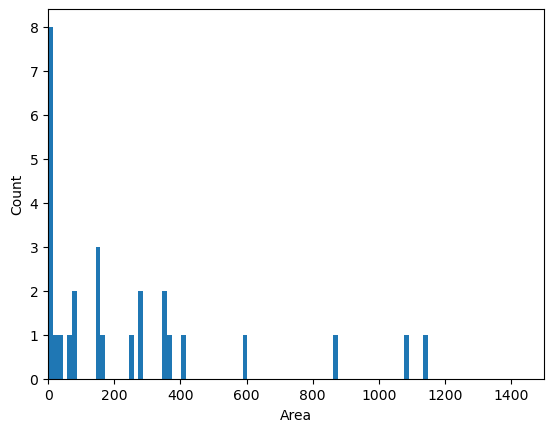

In [54]:
ax = areas_series.plot.hist(bins=80)
ax.set_xlim(0, 1500)
ax.set_xlabel('Area')
ax.set_ylabel('Count')
plt.show()

In [55]:
polygon_list_cleaned = [polygon for polygon in polygon_list if polygon.area >= 200]
polygon_list_cleaned

[<POLYGON ((326 115.5, 325 115.5, 324 115.5, 323 115.5, 322 115.5, 321.5 115,...>,
 <POLYGON ((860 146.5, 859.5 146, 859 145.5, 858 145.5, 857 145.5, 856.5 145,...>,
 <POLYGON ((236 273.5, 235 273.5, 234 273.5, 233 273.5, 232 273.5, 231 273.5,...>,
 <POLYGON ((264 284.5, 263 284.5, 262.5 284, 262 283.5, 261.5 284, 261 284.5,...>,
 <POLYGON ((525 329.5, 524 329.5, 523 329.5, 522 329.5, 521.5 329, 521 328.5,...>,
 <POLYGON ((533 372.5, 532 372.5, 531 372.5, 530.5 372, 530 371.5, 529 371.5,...>,
 <POLYGON ((277 475.5, 276 475.5, 275 475.5, 274 475.5, 273.5 475, 273.5 474,...>,
 <POLYGON ((714 561.5, 713 561.5, 712 561.5, 711 561.5, 710.5 561, 710 560.5,...>,
 <POLYGON ((321 632.5, 320 632.5, 319 632.5, 318 632.5, 317.5 632, 317 631.5,...>,
 <POLYGON ((973 652.5, 972.5 652, 972.5 651, 972.5 650, 972 649.5, 971 649.5,...>,
 <POLYGON ((333 719.5, 332 719.5, 331.5 719, 331 718.5, 330 718.5, 329 718.5,...>]

In [134]:
df = adata.obs.copy()
cell_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['X_centroid'], df['Y_centroid']))

cell_gdf

,Object,area,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,geometry
Object 1 in TS-373_IMC77_B_001.csv,1,16,0.562500,801.750000,8.430760,2.420699,0.957893,26.019224,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM,POINT (801.75 0.562)
Object 2 in TS-373_IMC77_B_001.csv,2,12,0.833333,859.583333,5.176698,2.940449,0.823017,84.005952,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM,POINT (859.583 0.833)
Object 3 in TS-373_IMC77_B_001.csv,3,13,0.846154,34.000000,5.203549,3.076923,0.806443,123.405835,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM,POINT (34 0.846)
Object 4 in TS-373_IMC77_B_001.csv,4,9,1.000000,42.000000,3.265986,3.265986,0.000000,118.713942,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM,POINT (42 1)
Object 5 in TS-373_IMC77_B_001.csv,5,23,1.478261,57.565217,8.151264,3.901335,0.878024,110.476242,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM,POINT (57.565 1.478)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,6622,11,998.000000,883.545455,4.077022,3.677860,0.431538,250.503493,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM,POINT (883.545 998)
Object 6623 in TS-373_IMC83_B_001.csv,6623,27,997.407407,978.703704,7.171071,5.069573,0.707266,327.273586,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM,POINT (978.704 997.407)
Object 6624 in TS-373_IMC83_B_001.csv,6624,25,997.640000,996.320000,7.554137,4.235920,0.827991,342.067245,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM,POINT (996.32 997.64)
Object 6625 in TS-373_IMC83_B_001.csv,6625,13,997.692308,820.153846,5.547002,3.412473,0.788377,195.256242,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM,POINT (820.154 997.692)


In [241]:
all_cells_in_polygons_list = []
MIN_VECTOR_AREA = 200
MIN_PIXEL_AREA = 200

for img in cell_gdf['image_ID'].unique():
    img_name = img.replace('.csv', '.tiff')
    mask = tiff.imread(f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/MK masks/{img_name}')
    cells_in_image = cell_gdf[cell_gdf['image_ID'] == img]
    binary_mask = (mask == 1)
    binary_mask = morphology.remove_small_objects(binary_mask, min_size=MIN_PIXEL_AREA).astype(np.uint8)
    contours = measure.find_contours(binary_mask, 0.5)
    img_polygon_list = []
    for contour in contours:
        if contour.shape[0] < 4:
            continue
        polygon_verts = contour[:, [1, 0]]
        polygon = Polygon(polygon_verts)
        if polygon.area >= MIN_VECTOR_AREA:
            img_polygon_list.append({
                'geometry': polygon,
                'image_ID': img,
                'area': polygon.area
            })
    if not img_polygon_list:
        continue

    image_mask_gdf = gpd.GeoDataFrame(img_polygon_list, crs=cells_in_image.crs)
    joinged_gdf = gpd.sjoin(cells_in_image, image_mask_gdf, how='inner', predicate='within')
    all_cells_in_polygons_list.append(joinged_gdf)

In [242]:
all_cells_in_polygons = pd.concat(all_cells_in_polygons_list, ignore_index=True)
all_cells_in_polygons

,Object,area_left,Y_centroid,X_centroid,axis_major_length,axis_minor_length,eccentricity,distance_to_bone,image_ID_left,disease,...,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,geometry,index_right,image_ID_right,area_right
0,821,103,115.203883,588.941748,12.229539,10.805004,0.468399,27.784888,TS-373_IMC03_MGUS_002.csv,MGUS/SMM,...,MGUS,27.784888,ADIPOCYTES_PC,PCs,4.295356,MGUS,POINT (588.942 115.204),0,TS-373_IMC03_MGUS_002.csv,339.5
1,829,141,116.971631,577.936170,13.575996,13.219803,0.227564,37.000000,TS-373_IMC03_MGUS_002.csv,MGUS/SMM,...,MGUS,37.000000,PC_MYELOID,PCs,4.497231,MGUS,POINT (577.936 116.972),0,TS-373_IMC03_MGUS_002.csv,339.5
2,950,193,140.829016,387.481865,17.836306,14.017176,0.618380,136.359818,TS-373_IMC03_MGUS_002.csv,MGUS/SMM,...,MGUS,136.359818,PROLIF_GLYC,PCs,3.788658,MGUS,POINT (387.482 140.829),1,TS-373_IMC03_MGUS_002.csv,303.5
3,1609,103,243.097087,160.368932,13.406220,10.064019,0.660646,48.010416,TS-373_IMC03_MGUS_002.csv,MGUS/SMM,...,MGUS,48.010416,PC_MYELOID,PCs,3.435780,MGUS,POINT (160.369 243.097),2,TS-373_IMC03_MGUS_002.csv,298.5
4,1643,41,249.707317,162.439024,9.004977,5.952438,0.750371,41.231056,TS-373_IMC03_MGUS_002.csv,MGUS/SMM,...,MGUS,41.231056,PC_MYELOID,PCs,3.885778,MGUS,POINT (162.439 249.707),2,TS-373_IMC03_MGUS_002.csv,298.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009,6362,244,931.430328,863.340164,19.190926,16.901129,0.473705,194.401646,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,194.401646,ADIPOCYTES_PC,PCs,4.658850,MM,POINT (863.34 931.43),6,TS-373_IMC83_B_001.csv,971.5
2010,6366,87,931.827586,878.908046,11.323385,9.858652,0.491911,208.021633,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,208.021633,PC_MYELOID,PCs,3.934625,MM,POINT (878.908 931.828),6,TS-373_IMC83_B_001.csv,971.5
2011,6383,49,938.795918,882.755102,9.057903,6.945989,0.641835,215.295146,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,215.295146,ADIPOCYTES_PC,PCs,3.258133,MM,POINT (882.755 938.796),6,TS-373_IMC83_B_001.csv,971.5
2012,6391,146,941.041096,872.383562,14.579974,13.026932,0.449101,207.460840,TS-373_IMC83_B_001.csv,MM_BD,...,MM_BD,207.460840,ADIPOCYTES_PC,PCs,4.495313,MM,POINT (872.384 941.041),6,TS-373_IMC83_B_001.csv,971.5


In [243]:
subset_keys = all_cells_in_polygons[['Object', 'image_ID_left']].copy()
subset_keys['inside_polygon'] = True
subset_keys.rename(columns={'image_ID_left': 'image_ID'}, inplace=True)

In [244]:
df = pd.merge(adata.to_df(),adata.obs, left_index=True, right_index=True)
df

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,image_ID,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3
Object 1 in TS-373_IMC77_B_001.csv,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM
Object 2 in TS-373_IMC77_B_001.csv,0.437678,0.425806,0.730220,0.539852,0.814078,0.153551,0.202306,0.000000,0.670883,0.632502,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM
Object 3 in TS-373_IMC77_B_001.csv,0.187705,0.185489,1.009269,0.506163,0.770498,0.041015,0.347042,0.075689,0.889004,0.901242,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM
Object 4 in TS-373_IMC77_B_001.csv,0.367975,0.144265,0.593424,0.173114,0.517508,0.062037,0.253639,0.199798,0.712216,0.430238,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM
Object 5 in TS-373_IMC77_B_001.csv,0.544195,0.216297,0.881555,0.338833,0.487923,0.049646,0.195340,0.000000,0.475726,0.511521,...,TS-373_IMC77_B_001.csv,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6622 in TS-373_IMC83_B_001.csv,0.630851,0.510358,0.851935,0.611909,0.717809,0.386979,0.513777,0.287785,1.042704,0.817466,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM
Object 6623 in TS-373_IMC83_B_001.csv,0.709539,0.382684,0.763277,0.516783,0.650090,0.341883,0.793174,0.214325,0.922652,0.636815,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM
Object 6624 in TS-373_IMC83_B_001.csv,0.702654,0.439202,0.623626,0.600737,0.834559,0.405722,0.725622,0.256038,0.877806,0.622458,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM
Object 6625 in TS-373_IMC83_B_001.csv,0.612524,0.427313,0.749995,0.585002,0.678468,0.399090,0.715312,0.193437,0.902942,0.605583,...,TS-373_IMC83_B_001.csv,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM


In [245]:
master_df = df.merge(subset_keys, on=['Object', 'image_ID'], how='left')
master_df['inside_polygon'] = master_df['inside_polygon'].fillna(False)

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/3957773220.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df['inside_polygon'] = master_df['inside_polygon'].fillna(False)


In [246]:
master_df[master_df['inside_polygon'] == True]

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,inside_polygon
6912,0.767297,0.381218,0.314736,0.675290,0.556065,0.111693,0.223074,0.146290,0.414328,0.562286,...,MGUS/SMM,IMC03,002,MGUS,27.784888,ADIPOCYTES_PC,PCs,4.295356,MGUS,True
6920,0.721194,0.360237,0.321439,0.630210,0.572676,0.077813,0.275746,0.144771,0.427997,0.574908,...,MGUS/SMM,IMC03,002,MGUS,37.000000,PC_MYELOID,PCs,4.497231,MGUS,True
7041,0.688403,0.349540,0.261579,0.542520,0.503501,0.126761,0.513519,0.101121,0.229346,0.489452,...,MGUS/SMM,IMC03,002,MGUS,136.359818,PROLIF_GLYC,PCs,3.788658,MGUS,True
7699,0.701458,0.279901,0.214423,0.614228,0.598104,0.117169,0.370614,0.139428,0.288059,0.558840,...,MGUS/SMM,IMC03,002,MGUS,48.010416,PC_MYELOID,PCs,3.435780,MGUS,True
7733,0.732106,0.325768,0.230744,0.674182,0.541742,0.103030,0.403935,0.151130,0.172451,0.573554,...,MGUS/SMM,IMC03,002,MGUS,41.231056,PC_MYELOID,PCs,3.885778,MGUS,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006862,0.618201,0.284679,0.302486,0.669776,0.302146,0.120038,0.626195,0.101479,0.736761,0.556509,...,MM_BD,IMC83,001,MM_BD,194.401646,ADIPOCYTES_PC,PCs,4.658850,MM,True
1006866,0.639665,0.294883,0.254425,0.700123,0.252164,0.168280,0.830178,0.118375,0.590505,0.588229,...,MM_BD,IMC83,001,MM_BD,208.021633,PC_MYELOID,PCs,3.934625,MM,True
1006883,0.633111,0.326218,0.215086,0.771875,0.154549,0.110524,0.847493,0.126878,0.559553,0.591703,...,MM_BD,IMC83,001,MM_BD,215.295146,ADIPOCYTES_PC,PCs,3.258133,MM,True
1006891,0.604866,0.279274,0.191508,0.740157,0.172616,0.147143,0.783771,0.130209,0.549262,0.561833,...,MM_BD,IMC83,001,MM_BD,207.460840,ADIPOCYTES_PC,PCs,4.495313,MM,True


In [247]:
print(master_df)

             CD38  Perilipin  Vimentin   B4GALT1       MPO  CathepsinK  \
0        0.285836   0.294962  0.381280  0.208380  0.470309    0.000000   
1        0.437678   0.425806  0.730220  0.539852  0.814078    0.153551   
2        0.187705   0.185489  1.009269  0.506163  0.770498    0.041015   
3        0.367975   0.144265  0.593424  0.173114  0.517508    0.062037   
4        0.544195   0.216297  0.881555  0.338833  0.487923    0.049646   
...           ...        ...       ...       ...       ...         ...   
1007122  0.630851   0.510358  0.851935  0.611909  0.717809    0.386979   
1007123  0.709539   0.382684  0.763277  0.516783  0.650090    0.341883   
1007124  0.702654   0.439202  0.623626  0.600737  0.834559    0.405722   
1007125  0.612524   0.427313  0.749995  0.585002  0.678468    0.399090   
1007126  0.658025   0.362593  0.802902  0.623439  0.631292    0.341972   

            ATP5A     RUNX2     HIF1A     CD11b  ...  disease  patient_ID  \
0        0.347032  0.118177  0.245

In [248]:
master_df[master_df['inside_polygon'] == True]['image_ID'].nunique()

132

Rate of mk-related missclassification across all cells, acorss images, across phenotypes per image
Analyze PC-CD138/IRF expression inside MKs compare to 'correct' PCs

In [249]:
# safer f-string quoting and use boolean mean for the proportion
print(f"The proportion of missclassified cells due to MKs is {master_df['inside_polygon'].mean():.6f}")

The proportion of missclassified cells due to MKs is 0.002000


In [250]:
pcs = master_df[master_df['Phenotype4'] == 'PCs']
print(f'The proportion of PCs missclassified due to MKs is {pcs["inside_polygon"].mean():.6f}')

The proportion of PCs missclassified due to MKs is 0.004939


In [251]:
rates_df = master_df.groupby(['image_ID'])['inside_polygon'] \
                 .mean() \
                 .reset_index(name='rate_misclassified')
rates_df

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/714405522.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates_df = master_df.groupby(['image_ID'])['inside_polygon'] \


,image_ID,rate_misclassified
0,TS-373_IMC01_UB_001.csv,0.002126
1,TS-373_IMC01_UB_002.csv,0.003397
2,TS-373_IMC02_MGUS_001.csv,0.004228
3,TS-373_IMC02_MGUS_002.csv,0.002074
4,TS-373_IMC03_MGUS_001.csv,0.001001
...,...,...
147,TS-373_IMC93_B_002.csv,0.000670
148,TS-373_IMC95_B_001.csv,0.000225
149,TS-373_IMC95_B_002.csv,0.000375
150,TS-373_IMC96_B_001.csv,0.001040


In [252]:
disease_map = master_df[['disease3', 'image_ID']].drop_duplicates()
disease_map = disease_map.set_index('image_ID')

In [253]:
rates_df['disease'] = rates_df['image_ID'].map(disease_map['disease3'])
rates_df['rate_misclassified'] *= 100
rates_df

,image_ID,rate_misclassified,disease
0,TS-373_IMC01_UB_001.csv,0.212565,MM
1,TS-373_IMC01_UB_002.csv,0.339674,MM
2,TS-373_IMC02_MGUS_001.csv,0.422800,MGUS
3,TS-373_IMC02_MGUS_002.csv,0.207383,MGUS
4,TS-373_IMC03_MGUS_001.csv,0.100120,MGUS
...,...,...,...
147,TS-373_IMC93_B_002.csv,0.067047,MM
148,TS-373_IMC95_B_001.csv,0.022502,MM
149,TS-373_IMC95_B_002.csv,0.037472,MM
150,TS-373_IMC96_B_001.csv,0.104046,MM


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/794862755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rates_df, x='disease', y='rate_misclassified', palette=disease3_color_map, showcaps=False, linewidth=2, width=0.75)


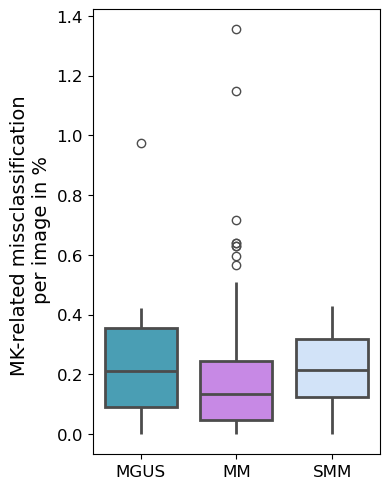

In [254]:
fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=rates_df, x='disease', y='rate_misclassified', palette=disease3_color_map, showcaps=False, linewidth=2, width=0.75)
plt.xlabel('')
plt.ylabel('MK-related missclassification \n per image in %', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

In [255]:
master_df

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,disease,patient_ID,ROI,disease2,distance_to_bone_corrected,cellcharter_CN,Phenotype4,HistoneH3,disease3,inside_polygon
0,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,MM_BD,IMC77,001,MM_BD,26.019224,ADIPOCYTES_PC,PCs,4.374106,MM,False
1,0.437678,0.425806,0.730220,0.539852,0.814078,0.153551,0.202306,0.000000,0.670883,0.632502,...,MM_BD,IMC77,001,MM_BD,84.005952,BONE_ADIPOCYTES,Unknown,3.578988,MM,False
2,0.187705,0.185489,1.009269,0.506163,0.770498,0.041015,0.347042,0.075689,0.889004,0.901242,...,MM_BD,IMC77,001,MM_BD,123.405835,HIF1A_IMMUNE,Neutrophils,2.832795,MM,False
3,0.367975,0.144265,0.593424,0.173114,0.517508,0.062037,0.253639,0.199798,0.712216,0.430238,...,MM_BD,IMC77,001,MM_BD,118.713942,ADIPOCYTES_PC,Unknown,2.353134,MM,False
4,0.544195,0.216297,0.881555,0.338833,0.487923,0.049646,0.195340,0.000000,0.475726,0.511521,...,MM_BD,IMC77,001,MM_BD,110.476242,PC_MYELOID,Unknown,3.813037,MM,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007122,0.630851,0.510358,0.851935,0.611909,0.717809,0.386979,0.513777,0.287785,1.042704,0.817466,...,MM_BD,IMC83,001,MM_BD,250.503493,HIF1A_IMMUNE,Neutrophils,4.890736,MM,False
1007123,0.709539,0.382684,0.763277,0.516783,0.650090,0.341883,0.793174,0.214325,0.922652,0.636815,...,MM_BD,IMC83,001,MM_BD,327.273586,PC_MYELOID,CD4 T,4.770726,MM,False
1007124,0.702654,0.439202,0.623626,0.600737,0.834559,0.405722,0.725622,0.256038,0.877806,0.622458,...,MM_BD,IMC83,001,MM_BD,342.067245,BONE_MYELOID,Neutrophils,5.153814,MM,False
1007125,0.612524,0.427313,0.749995,0.585002,0.678468,0.399090,0.715312,0.193437,0.902942,0.605583,...,MM_BD,IMC83,001,MM_BD,195.256242,PC_MYELOID,HLA-DR+ Macs/monos,4.905291,MM,False


In [256]:
master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'].mean()

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/1579693656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'].mean()


image_ID                 Phenotype4 
TS-373_IMC01_UB_001.csv  Adipocytes     0.000000
                         CD4 T          0.000000
                         CD8 T          0.000000
                         DCs            0.000000
                         Endothelial    0.000000
                                          ...   
TS-373_IMC96_B_002.csv   OB/RUNX2+      0.000000
                         Osteoclasts    0.000000
                         Osteocytes          NaN
                         PCs            0.026891
                         Unknown        0.000000
Name: inside_polygon, Length: 2280, dtype: float64

In [257]:
rates_df = master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'] \
                         .mean() \
                         .reset_index(name='misclassification_rate')
rates_df['misclassification_rate'] *= 100

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/652096656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates_df = master_df.groupby(['image_ID', 'Phenotype4'])['inside_polygon'] \


In [258]:
rates_df

,image_ID,Phenotype4,misclassification_rate
0,TS-373_IMC01_UB_001.csv,Adipocytes,0.000000
1,TS-373_IMC01_UB_001.csv,CD4 T,0.000000
2,TS-373_IMC01_UB_001.csv,CD8 T,0.000000
3,TS-373_IMC01_UB_001.csv,DCs,0.000000
4,TS-373_IMC01_UB_001.csv,Endothelial,0.000000
...,...,...,...
2275,TS-373_IMC96_B_002.csv,OB/RUNX2+,0.000000
2276,TS-373_IMC96_B_002.csv,Osteoclasts,0.000000
2277,TS-373_IMC96_B_002.csv,Osteocytes,NaN
2278,TS-373_IMC96_B_002.csv,PCs,2.689076


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/2656577112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rates_df, x='Phenotype4', y='misclassification_rate', palette=phenotype_color_map, linewidth=2, width=0.75, capsize=0.25, edgecolor='black', errcolor='black')
/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_39045/2656577112.py:2: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(data=rates_df, x='Phenotype4', y='misclassification_rate', palette=phenotype_color_map, linewidth=2, width=0.75, capsize=0.25, edgecolor='black', errcolor='black')


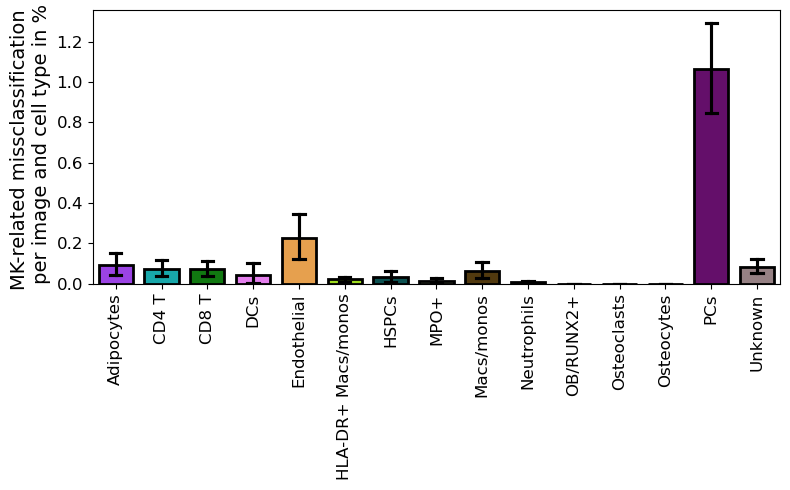

In [259]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rates_df, x='Phenotype4', y='misclassification_rate', palette=phenotype_color_map, linewidth=2, width=0.75, capsize=0.25, edgecolor='black', errcolor='black')
plt.xlabel('')
plt.ylabel(f'MK-related missclassification \n per image and cell type in %', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.tight_layout()